# 4. Exploratory Data Analysis

Verifies the derivation decisions from Notebooks 1-3 against the actual analytic data before any
modeling: survey design properties, missingness structure, the two measurement fixes made along the
way (Household Autonomy, IPV Attitude), univariate and bivariate distributions, and multicollinearity
in the candidate adjustment set.

Two scope notes worth stating plainly up front, since both have come up in review:

- **Population.** BDHS's women's questionnaire covers ever-married women by design (that's the whole
  eligible frame, 30,078 in this round). This analysis narrows further to *currently* married women
  (`S111A == 1`, Section 2) -- a deliberate restriction, not an oversight, because several covariates
  used downstream (Partner occupation, Household Autonomy, IPV Attitude) only make sense relative to
  a co-resident husband and aren't defined for widowed, divorced, or separated women.
- **Cardiometabolic burden.** Built from diabetes, hypertension, and obesity -- not dyslipidemia.
  That's not a scope-narrowing choice; BDHS's biomarker module doesn't collect a lipid panel (that
  needs venous blood and lab processing that the standard DHS biomarker round doesn't do), so
  dyslipidemia was never available to include.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import patsy
import missingno as msno

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("crest", 8)
plt.rcParams["figure.dpi"] = 110

In [2]:
df_depression = pd.read_csv("../resources/depression_dataset.csv")
df_anxiety = pd.read_csv("../resources/anxiety_dataset.csv")

print("df_depression:", df_depression.shape)
print("df_anxiety:  ", df_anxiety.shape)
df_depression.head()

df_depression: (4887, 27)
df_anxiety:   (4887, 27)


,Cardiometabolic Burden,Socioeconomic Status,Depression,Education,Occupation,Partner occupation,Age,Division,Residence,Religion,Children,Family size,Household Autonomy,Financial Decision-Making,IPV Attitude,Insurance,Internet,Contraceptive,Abortion,Pregnant,Menopause,Sexual activity,Postpartum,CASEID,Sampling weight,PSU,Stratum
0,3,5,1,3,0.0,1,3,1,1,1,2,1,3,1,0,0.0,0,0.0,1,0,0,0,0,1 1 3,0.156207,1,1
1,0,4,1,0,1.0,2,3,1,1,2,1,1,3,0,0,0.0,0,2.0,0,0,0,1,0,1 18 2,0.156207,1,1
2,0,4,0,2,1.0,2,1,1,1,1,1,1,0,0,0,0.0,0,0.0,0,1,0,1,0,1 35 2,0.156207,1,1
3,0,4,0,2,0.0,2,2,1,1,2,0,1,3,0,0,0.0,2,0.0,0,0,0,1,0,1 52 2,0.156207,1,1
4,0,5,0,2,0.0,2,3,1,1,2,1,1,3,0,0,0.0,0,0.0,1,0,0,0,0,1 69 2,0.156207,1,1


## 1. Survey Design Overview

In [3]:
design_summary = pd.DataFrame({
    "n_obs": [len(df_depression)],
    "unique_PSU": [df_depression["PSU"].nunique()],
    "unique_Stratum": [df_depression["Stratum"].nunique()],
    "weight_min": [df_depression["Sampling weight"].min()],
    "weight_max": [df_depression["Sampling weight"].max()],
    "weight_mean": [df_depression["Sampling weight"].mean()],
    "sum_of_weights": [df_depression["Sampling weight"].sum()],
})
design_summary.index = ["depression sample"]
design_summary

,n_obs,unique_PSU,unique_Stratum,weight_min,weight_max,weight_mean,sum_of_weights
depression sample,4887,674,16,0.091325,3.891736,0.992805,4851.835617


In [4]:
w = df_depression["Sampling weight"].values
deff_weighting = (len(w) * np.sum(w**2)) / (np.sum(w)**2)
n_eff = len(w) / deff_weighting
print(f"Weighting-only design effect (Kish):  {deff_weighting:.3f}")
print(f"Implied effective sample size:        {n_eff:,.0f}  (of {len(w):,} nominal)")

cluster_sizes = df_depression.groupby("PSU").size()
print(f"\nClusters: {df_depression['PSU'].nunique()}, smallest cluster: {cluster_sizes.min()} respondents")

Weighting-only design effect (Kish):  1.253
Implied effective sample size:        3,901  (of 4,887 nominal)

Clusters: 674, smallest cluster: 2 respondents


## 2. Missingness: Structural Sub-Sampling vs. Item-Level

In [5]:
raw = pd.read_csv("../resources/full_dataset.csv")
raw = raw[raw["S111A"] == 1]
print("Eligible currently-married women (pre-completeness-filter):", raw.shape[0])

diabetes_cols   = ["SB267", "SB236", "SB240"]
hyper_cols      = ["WBP24", "WBP25", "WBP16", "WBP19"]
obesity_cols    = ["HA40"]

biomarker_incomplete = (
    (raw[diabetes_cols].isna().sum(axis=1) >= 3) |
    (raw[hyper_cols].isna().sum(axis=1) >= 4) |
    (raw[obesity_cols].isna().sum(axis=1) >= 1)
)

depression_missing = raw["MTH22"].isna()
occ_ins_abuse_missing = raw[["V744A","V744B","V744C","V744D","V744E"]].isna().all(axis=1)
autonomy_partner_missing = raw[["V743A","V743B","V743D"]].isna().all(axis=1)

overlap = pd.DataFrame({
    "block size": [depression_missing.sum(), occ_ins_abuse_missing.sum(), autonomy_partner_missing.sum()],
    "within biomarker-incomplete": [
        (depression_missing & biomarker_incomplete).sum(),
        (occ_ins_abuse_missing & biomarker_incomplete).sum(),
        (autonomy_partner_missing & biomarker_incomplete).sum(),
    ],
}, index=["Depression/Anxiety (MTH22/24) missing", "Occupation+Insurance+Abuse-attitudes missing (all-NaN block)",
          "Household-decision items (V743A/B/D) missing (all-NaN block)"])
overlap["% explained by biomarker sub-sample"] = (overlap["within biomarker-incomplete"] / overlap["block size"] * 100).round(1)
overlap

Eligible currently-married women (pre-completeness-filter): 28537


,block size,within biomarker-incomplete,% explained by biomarker sub-sample
Depression/Anxiety (MTH22/24) missing,9550,9550,100.0
Occupation+Insurance+Abuse-attitudes missing (all-NaN block),9550,9550,100.0
Household-decision items (V743A/B/D) missing (all-NaN block),9550,9550,100.0


The depression/anxiety, occupation/insurance/IPV-attitude block is missing for exactly the same
women who lack biomarkers (same extended-module sub-sample) -- 100% overlap, not a coincidence.
The residual household-decision-item missingness is driven purely by that same overlap now: with the
currently-married-only filter in place, there's no separate "not married, item doesn't apply"
component left in it.

In [6]:
weight_like_cols = [c for c in raw.columns if c.upper() in ("V005", "SW", "BW", "MW")]
print("Weight-like columns present in the extract:", weight_like_cols)

Weight-like columns present in the extract: ['V005']


### 2.2 Analytic sample vs. eligible population

The biomarker-completeness filter drops 23,650 of the 28,537 eligible women -- worth checking
directly whether the 4,887 who remain still look like the eligible population on the variables that
matter most for this analysis (wealth, age, division), or whether the biomarker sub-sample skews
sharply on any of them.

In [7]:
raw_elig = raw.copy()
raw_elig["Sampling weight"] = raw_elig["V005"] / 1_000_000
raw_elig["in_analytic_sample"] = raw_elig["CASEID"].isin(df_depression["CASEID"])
raw_elig["age_grp"] = pd.cut(raw_elig["V012"], bins=[14, 24, 34, 49], labels=["15-24", "25-34", "35-49"])

wealth_map = {1: "Poorest", 2: "Poorer", 3: "Middle", 4: "Richer", 5: "Richest"}
division_map = {1: "Barishal", 2: "Chattogram", 3: "Dhaka", 4: "Khulna", 5: "Mymensingh",
                6: "Rajshahi", 7: "Rangpur", 8: "Sylhet"}

def weighted_pct(data, col, mapping=None):
    g = data.groupby(col)["Sampling weight"].sum()
    pct = (g / g.sum() * 100).round(1)
    if mapping:
        pct.index = [mapping.get(i, i) for i in pct.index]
    return pct

rows = []
for label, col, mapping in [("Wealth quintile", "V190", wealth_map),
                             ("Age group", "age_grp", None),
                             ("Division", "V024", division_map)]:
    elig_pct = weighted_pct(raw_elig, col, mapping)
    analytic_pct = weighted_pct(raw_elig[raw_elig["in_analytic_sample"]], col, mapping)
    for cat in elig_pct.index:
        rows.append({"Variable": label, "Category": cat,
                      "Eligible (n=28,537) %": elig_pct.get(cat, np.nan),
                      "Analytic (n=4,887) %": analytic_pct.get(cat, np.nan)})
compare_df = pd.DataFrame(rows)
compare_df["Difference (pp)"] = (compare_df["Analytic (n=4,887) %"] - compare_df["Eligible (n=28,537) %"]).round(1)
compare_df

,Variable,Category,"Eligible (n=28,537) %","Analytic (n=4,887) %",Difference (pp)
0,Wealth quintile,Poorest,18.2,17.5,-0.7
1,Wealth quintile,Poorer,20.1,20.0,-0.1
2,Wealth quintile,Middle,20.4,20.1,-0.3
3,Wealth quintile,Richer,20.7,20.8,0.1
4,Wealth quintile,Richest,20.6,21.7,1.1
5,Age group,15-24,25.6,23.4,-2.2
6,Age group,25-34,35.2,35.5,0.3
7,Age group,35-49,39.2,41.1,1.9
8,Division,Barishal,6.1,6.4,0.3
9,Division,Chattogram,18.5,19.1,0.6


Wealth and Division barely move (every difference under 1.2 points) -- the biomarker sub-sample
isn't systematically richer, poorer, or geographically skewed relative to the eligible population.
Age shifts a bit: 35-49 is overrepresented by about 2 points and 15-24 underrepresented by about the
same, consistent with older women being more available for (or more willing to complete) the
biomarker module. Worth a sentence in the manuscript's limitations, not a reason to doubt the sample
-- Age is already a covariate in every model, so this particular skew is exactly the kind of thing
adjustment handles.

### 2.1 Verifying the fixes

**Marital status / Partner occupation collinearity** — resolved as a side effect of the currently-married-only filter, not by a targeted fix: `Marital status` is now constant across the whole sample and has been dropped from the pipeline entirely.

In [8]:
print("'Marital status' column present in analytic data?", "Marital status" in df_depression.columns)
print("Partner occupation categories now:", sorted(df_depression["Partner occupation"].unique()))

'Marital status' column present in analytic data? False
Partner occupation categories now: [np.int64(1), np.int64(2), np.int64(3)]


**`Autonomy` silent-zero bug** — the underlying cause (not-currently-married women with all 4 items structurally missing) no longer exists in the sample, since everyone is now currently married. But the *fix itself* was about something broader: `V743F`'s "no earnings" case creates a real denominator mismatch regardless of marital status, and that's still live. Confirmed resolved below — `Household Autonomy` is now built from `V743A`/`V743B`/`V743D` only (zero missingness, no denominator inconsistency), and the `V743F` information is preserved separately in `Financial Decision-Making` rather than discarded.

In [9]:
print("Household Autonomy — any missing?", df_depression["Household Autonomy"].isna().sum())
print("Household Autonomy range:", sorted(df_depression["Household Autonomy"].unique()))
print()
print("Financial Decision-Making distribution (2 = 'No earnings', kept as its own category):")
print(df_depression["Financial Decision-Making"].value_counts().sort_index())
print(f"\n'No earnings' respondents: {(df_depression['Financial Decision-Making']==2).sum()} "
      f"({(df_depression['Financial Decision-Making']==2).mean()*100:.1f}% of the sample) — "
      "no longer forced into the Household Autonomy sum with a mismatched denominator.")

Household Autonomy — any missing? 0
Household Autonomy range: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Financial Decision-Making distribution (2 = 'No earnings', kept as its own category):
Financial Decision-Making
0    1585
1    3238
2      64
Name: count, dtype: int64

'No earnings' respondents: 64 (1.3% of the sample) — no longer forced into the Household Autonomy sum with a mismatched denominator.


`IPV Attitude` is now a 3-level variable instead of binary, so "don't know" responses get their own category rather than being silently folded into "does not justify" as before.

In [10]:
print("IPV Attitude distribution:")
print(df_depression["IPV Attitude"].value_counts().sort_index())
print(f"\n'Uncertain' (don't know, never affirms): {(df_depression['IPV Attitude']==1).sum()} "
      f"({(df_depression['IPV Attitude']==1).mean()*100:.1f}% of the sample)")

IPV Attitude distribution:
IPV Attitude
0    4174
1      62
2     651
Name: count, dtype: int64

'Uncertain' (don't know, never affirms): 62 (1.3% of the sample)


## 3. Univariate Distributions (Design-Weighted)

In [11]:
def weighted_props(data, col, weight_col="Sampling weight"):
    g = data.groupby(col, dropna=False)[weight_col].sum()
    return (g / g.sum() * 100).sort_index()

def unweighted_props(data, col):
    g = data[col].value_counts(dropna=False)
    return (g / g.sum() * 100).sort_index()

def compare_bar(data, col, ax, title=None, labels=None):
    w = weighted_props(data, col)
    u = unweighted_props(data, col)
    idx = w.index
    x = np.arange(len(idx))
    width = 0.38
    ax.bar(x - width/2, u.reindex(idx).values, width, label="Unweighted", color=PALETTE[2])
    ax.bar(x + width/2, w.reindex(idx).values, width, label="Weighted (V005)", color=PALETTE[6])
    ax.set_xticks(x)
    tick_labels = [labels[i] for i in idx] if labels else [str(i) for i in idx]
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_ylabel("%")
    ax.set_title(title or col)
    ax.legend(fontsize=8)

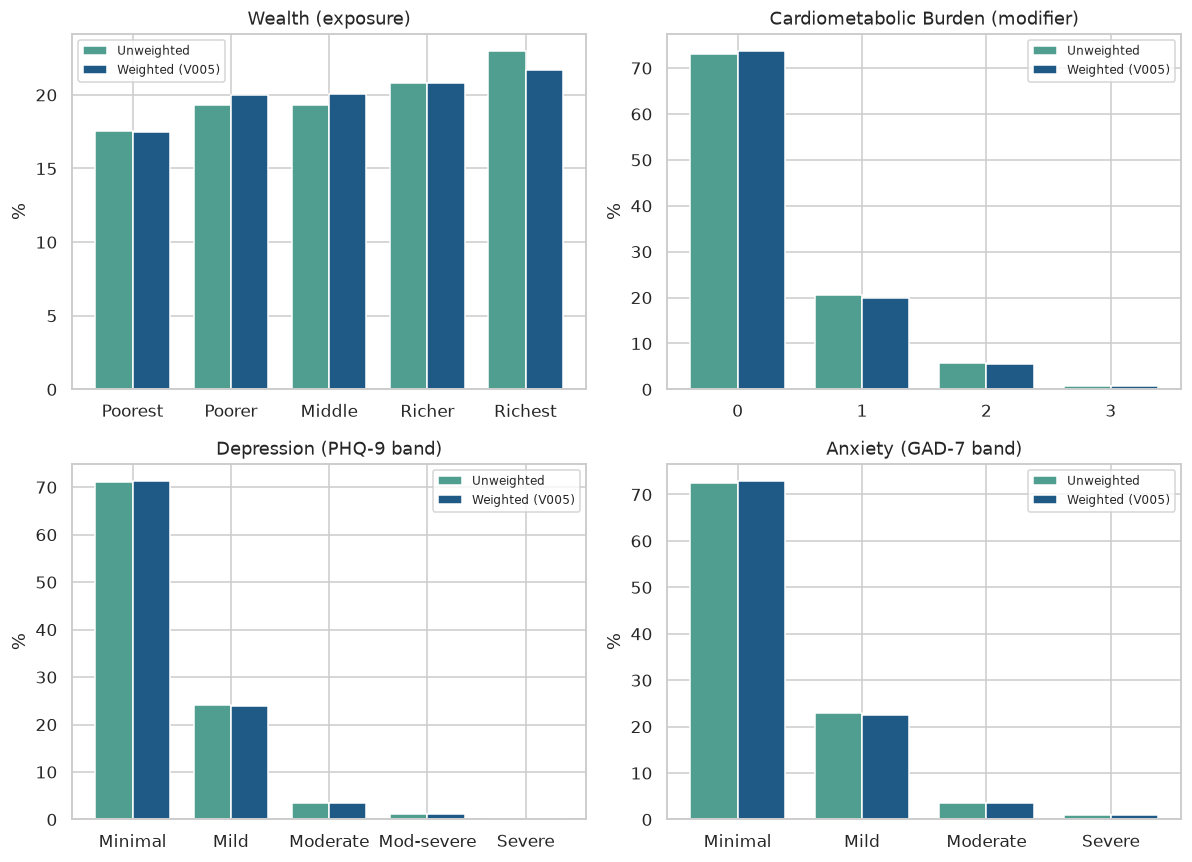

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

compare_bar(df_depression, "Socioeconomic Status", axes[0,0], "Wealth (exposure)",
            {1:"Poorest",2:"Poorer",3:"Middle",4:"Richer",5:"Richest"})
compare_bar(df_depression, "Cardiometabolic Burden", axes[0,1], "Cardiometabolic Burden (modifier)",
            {0:"0",1:"1",2:"2",3:"3"})
compare_bar(df_depression, "Depression", axes[1,0], "Depression (PHQ-9 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Mod-severe",4:"Severe"})
compare_bar(df_anxiety, "Anxiety", axes[1,1], "Anxiety (GAD-7 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Severe"})

plt.tight_layout()
plt.show()

### 3.1 Weighted prevalence with a design-aware confidence interval

The band charts above show the full severity distribution; here's the specific number the rest of
the analysis actually dichotomizes on -- probable-case prevalence -- with an interval around it
rather than a bare point estimate. Same cluster-robust-by-PSU approximation used everywhere else in
this Python pipeline (no `Stratum` term, flagged once here rather than every time it recurs).

In [13]:
import statsmodels.api as sm

def weighted_prevalence_ci(data, outcome_col, weight_col="Sampling weight", cluster_col="PSU"):
    y = data[outcome_col].values.astype(float)
    w = data[weight_col].values
    X = np.ones((len(y), 1))
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model = sm.GLM(y, X, family=sm.families.Gaussian(), var_weights=w)
        res = model.fit(cov_type="cluster", cov_kwds={"groups": data[cluster_col].values})
    est = float(np.asarray(res.params)[0])
    ci = np.asarray(res.conf_int())
    return est, ci[0, 0], ci[0, 1]

df_depression["Depression_binary"] = (df_depression["Depression"] >= 2).astype(int)
df_anxiety["Anxiety_binary"] = (df_anxiety["Anxiety"] >= 2).astype(int)

for label, data, col in [("Depression", df_depression, "Depression_binary"), ("Anxiety", df_anxiety, "Anxiety_binary")]:
    unweighted = data[col].mean()
    est, lo, hi = weighted_prevalence_ci(data, col)
    print(f"{label}: unweighted {unweighted:.1%}  |  weighted {est:.1%}  (95% CI {lo:.1%}-{hi:.1%}, cluster-robust by PSU)")

Depression: unweighted 4.8%  |  weighted 4.8%  (95% CI 4.0%-5.5%, cluster-robust by PSU)
Anxiety: unweighted 4.5%  |  weighted 4.6%  (95% CI 3.8%-5.3%, cluster-robust by PSU)


Weighted and unweighted prevalence land within a few tenths of a point of each other for both
outcomes -- weighting isn't dragging the headline numbers around. The CI width (about 1.5 points
either side) is the more useful number to carry forward: it's the honest precision behind "4.8%" and
"4.6%," and it's why Section 16's EPV discussion in Notebook 5 treats individual coefficients
cautiously -- a rare outcome with a CI this wide doesn't leave much room to spare once it's split
across dozens of model parameters.

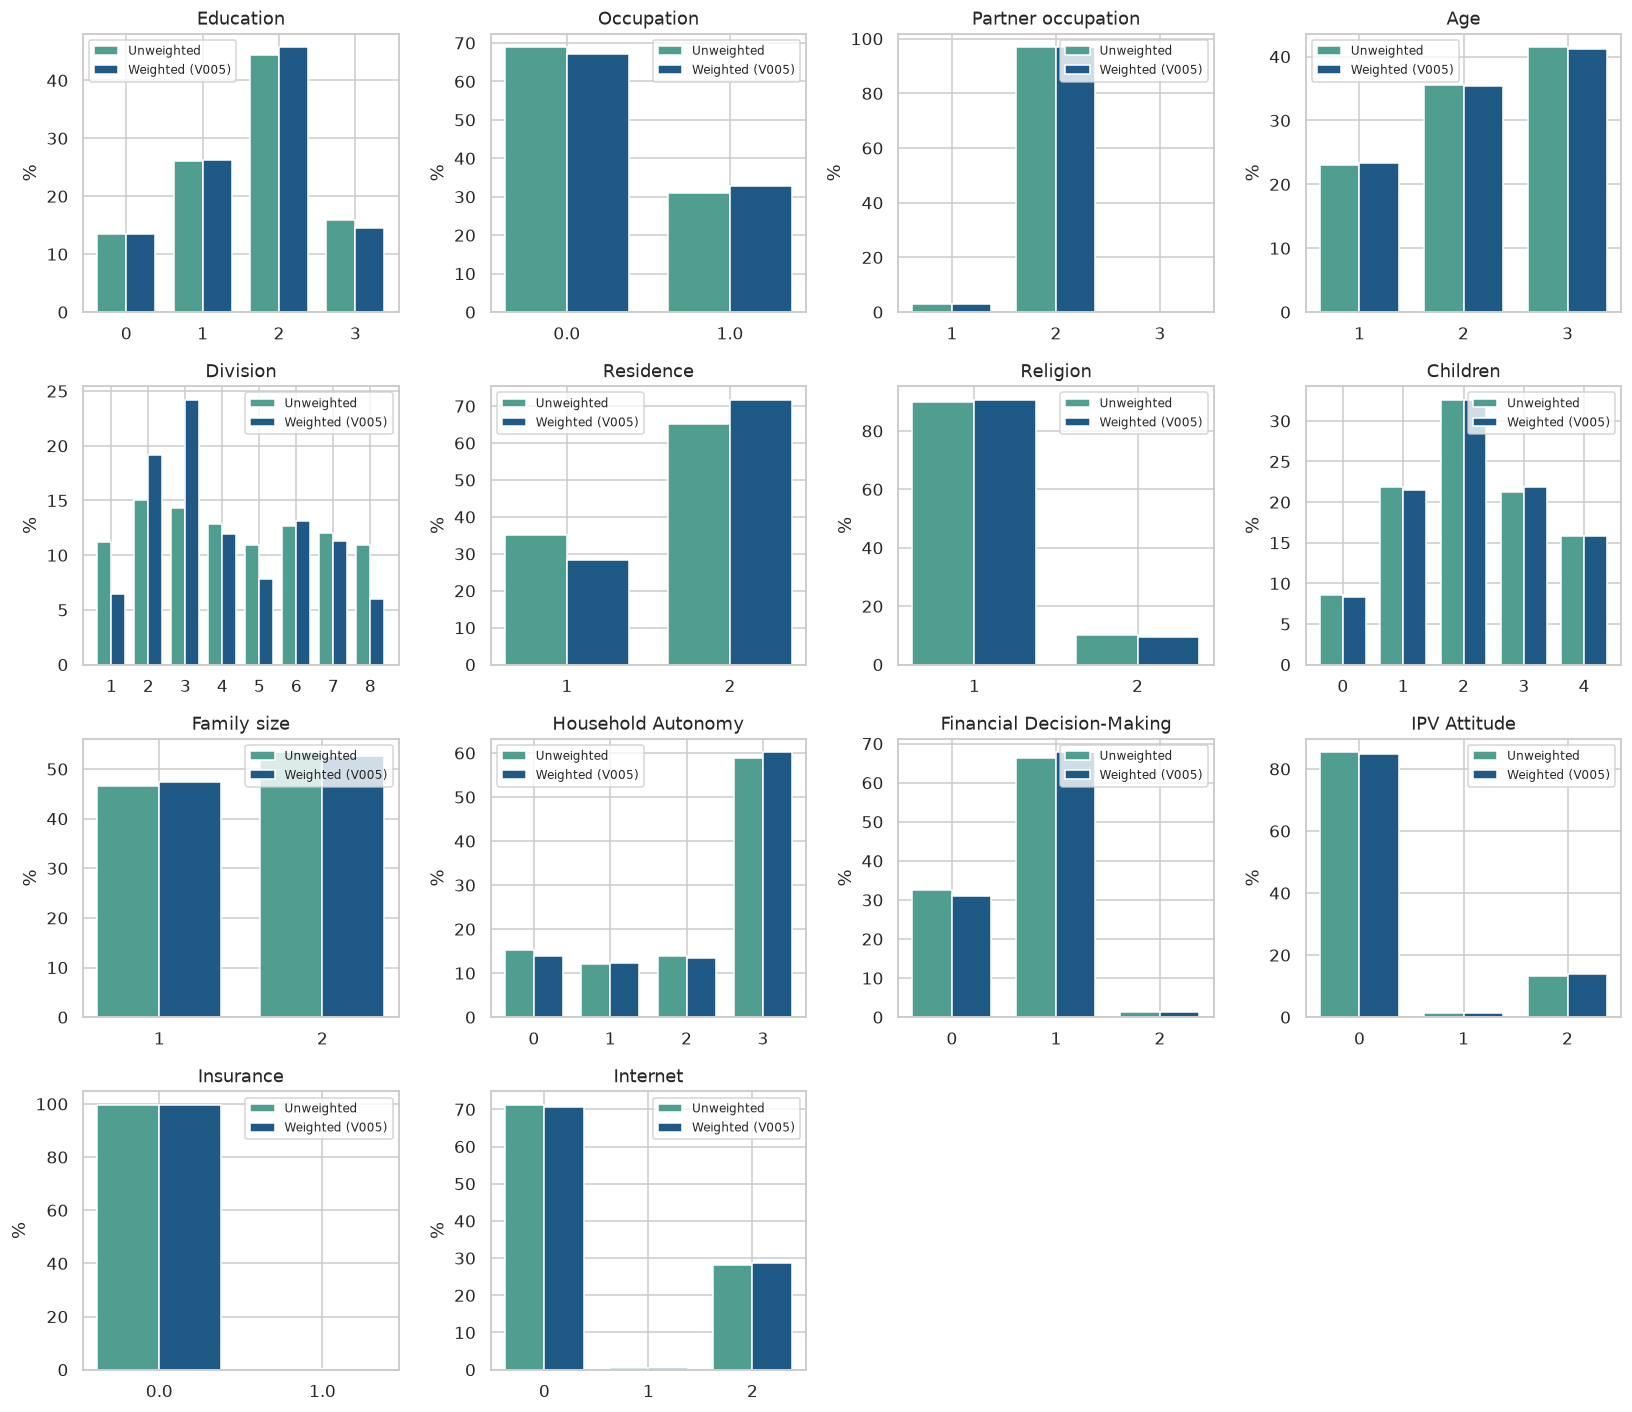

In [14]:
confounders = ["Education", "Occupation", "Partner occupation", "Age", "Division", "Residence",
               "Religion", "Children", "Family size", "Household Autonomy", "Financial Decision-Making",
               "IPV Attitude", "Insurance", "Internet"]

fig, axes = plt.subplots(4, 4, figsize=(15, 13))
axes = axes.flatten()
for i, col in enumerate(confounders):
    compare_bar(df_depression, col, axes[i], col)
for j in range(len(confounders), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

`Financial Decision-Making` and the 3-level `IPV Attitude` are both new to this section -- each has
a small third category (no-earnings; uncertain) visible but not dominant, consistent with the counts
confirmed in Section 2.1.

## 4. Bivariate Relationships and Cell Sparsity

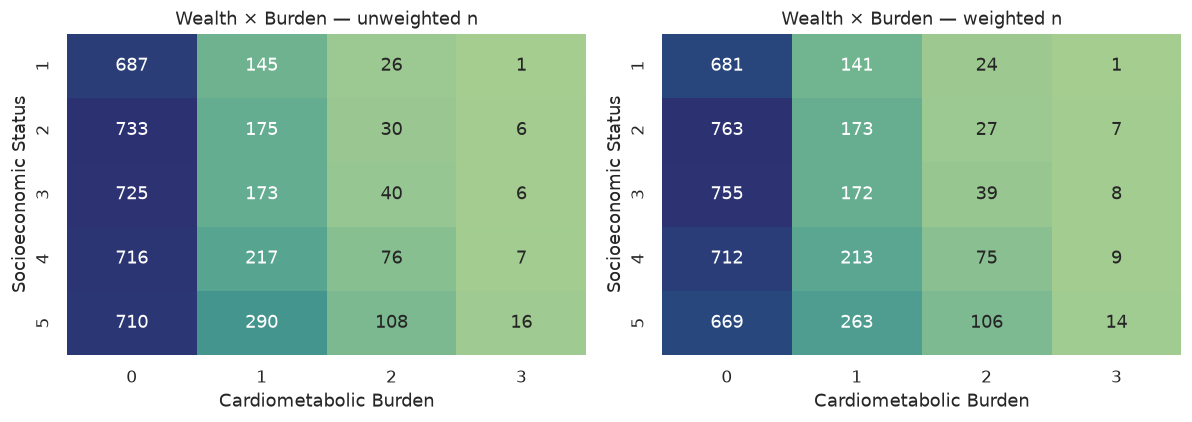

Smallest unweighted cell: 1


In [15]:
ct_unweighted = pd.crosstab(df_depression["Socioeconomic Status"], df_depression["Cardiometabolic Burden"])
ct_weighted = df_depression.pivot_table(index="Socioeconomic Status", columns="Cardiometabolic Burden",
                                         values="Sampling weight", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(ct_unweighted, annot=True, fmt="d", cmap="crest", ax=axes[0], cbar=False)
axes[0].set_title("Wealth × Burden — unweighted n")
sns.heatmap(ct_weighted, annot=True, fmt=".0f", cmap="crest", ax=axes[1], cbar=False)
axes[1].set_title("Wealth × Burden — weighted n")
plt.tight_layout()
plt.show()

print("Smallest unweighted cell:", ct_unweighted.values.min())

Same sparsity concern as before: the highest-burden, lowest-wealth cell remains thin. The recommendation is unchanged — treat `Cardiometabolic Burden` as ordinal/linear in the interaction term, or collapse categories 2/3, rather than fitting a fully saturated categorical interaction.

In [16]:
cell3 = df_depression.groupby(["Socioeconomic Status", "Cardiometabolic Burden", "Depression"]).size()
print(f"3-way cells: {len(cell3)} total, {int((cell3 == 0).sum())} empty, "
      f"minimum non-empty count = {cell3[cell3 > 0].min()}")
print(f"Cells with count < 5: {int((cell3 < 5).sum())} / {len(cell3)}")

3-way cells: 70 total, 0 empty, minimum non-empty count = 1
Cells with count < 5: 23 / 70


In [17]:
def naive_chi2(data, a, b, label):
    tab = pd.crosstab(data[a], data[b])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    print(f"{label:35s}  chi2={chi2:8.2f}  df={dof:3d}  p={p:.4g}")

print("Design-naive Pearson chi-sq screening (NOT the reported statistic):\n")
naive_chi2(df_depression, "Socioeconomic Status", "Cardiometabolic Burden", "Wealth × Burden")
naive_chi2(df_depression, "Socioeconomic Status", "Depression", "Wealth × Depression")
naive_chi2(df_depression, "Cardiometabolic Burden", "Depression", "Burden × Depression")
naive_chi2(df_anxiety, "Socioeconomic Status", "Anxiety", "Wealth × Anxiety")
naive_chi2(df_anxiety, "Cardiometabolic Burden", "Anxiety", "Burden × Anxiety")

Design-naive Pearson chi-sq screening (NOT the reported statistic):

Wealth × Burden                      chi2=  123.67  df= 12  p=1.145e-20
Wealth × Depression                  chi2=   31.71  df= 16  p=0.01089
Burden × Depression                  chi2=   14.86  df= 12  p=0.2493
Wealth × Anxiety                     chi2=   41.80  df= 12  p=3.602e-05
Burden × Anxiety                     chi2=   17.54  df=  9  p=0.04092


## 5. Multicollinearity: Generalized VIF (Fox & Monette, 1992)

`Marital status` is gone from the pipeline entirely -- nothing left that could cause the degenerate
GVIF it used to produce. Candidate set below is the 12 variables reconstructed from
`Supplementary Figure S1 (Full DAG).tex` (still including `Insurance` at this stage -- its exclusion
in Notebook 5 turns out to be a separation problem, not a collinearity one, and this section is
specifically about collinearity).

In [18]:
def calc_gvif(formula_rhs, data):
    '''Fox & Monette (1992) generalized VIF, one row per term.'''
    design = patsy.dmatrix(formula_rhs, data, return_type="dataframe")
    term_slices = design.design_info.term_name_slices
    X = design.drop(columns=["Intercept"], errors="ignore")
    R = X.corr().values
    detR = np.linalg.det(R)
    colnames = list(X.columns)

    rows = []
    for term, sl in term_slices.items():
        if term == "Intercept":
            continue
        cols = [c for c in design.columns[sl] if c != "Intercept"]
        idx = [colnames.index(c) for c in cols]
        other_idx = [i for i in range(len(colnames)) if i not in idx]
        d = len(idx)
        gvif = (np.linalg.det(R[np.ix_(idx, idx)]) * np.linalg.det(R[np.ix_(other_idx, other_idx)])) / detR
        rows.append((term.replace("C(Q('", "").replace("'))", ""), d, gvif, gvif ** (1 / (2 * d))))
    out = pd.DataFrame(rows, columns=["term", "Df", "GVIF", "GVIF^(1/(2*Df))"])
    return out.sort_values("GVIF^(1/(2*Df))", ascending=False).reset_index(drop=True)

exposure, modifier = "Socioeconomic Status", "Cardiometabolic Burden"
candidate_covariates = ["Education", "Occupation", "Partner occupation", "Age", "Division", "Residence",
                        "Religion", "Children", "Family size", "Household Autonomy", "Insurance", "Internet"]
model_vars = [exposure, modifier] + candidate_covariates
formula_rhs = " + ".join(f"C(Q('{v}'))" for v in model_vars)

gvif = calc_gvif(formula_rhs, df_depression[model_vars].dropna())
threshold = 2.0
gvif["flag"] = np.where(gvif["GVIF^(1/(2*Df))"] > threshold, "⚠ review", "OK")
gvif.style.format({"GVIF": "{:.3g}", "GVIF^(1/(2*Df))": "{:.3g}"})

,term,Df,GVIF,GVIF^(1/(2*Df)),flag
0,Age,2,2.19,1.22,OK
1,Children,4,2.34,1.11,OK
2,Education,3,1.85,1.11,OK
3,Residence,1,1.22,1.11,OK
4,Internet,2,1.39,1.09,OK
5,Family size,1,1.16,1.08,OK
6,Socioeconomic Status,4,1.79,1.08,OK
7,Occupation,1,1.1,1.05,OK
8,Cardiometabolic Burden,3,1.16,1.02,OK
9,Religion,1,1.05,1.02,OK


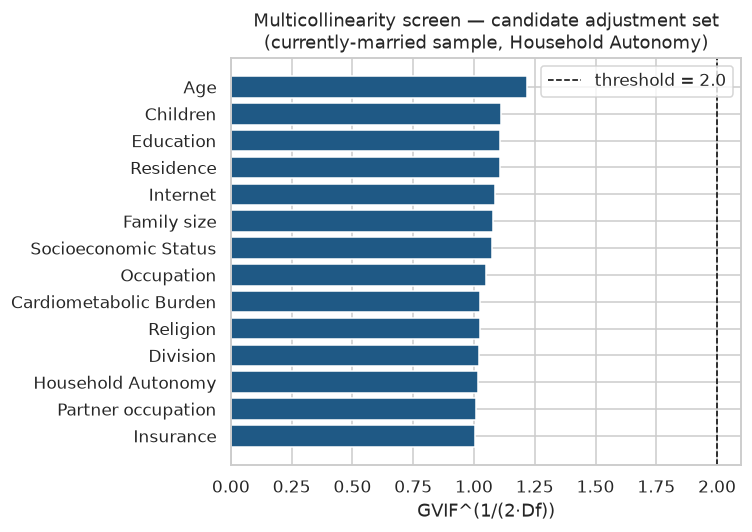

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
order = gvif.sort_values("GVIF^(1/(2*Df))")
colors = [PALETTE[6] if v <= threshold else "indianred" for v in order["GVIF^(1/(2*Df))"]]
ax.barh(order["term"], order["GVIF^(1/(2*Df))"], color=colors)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold = {threshold}")
ax.set_xlabel("GVIF^(1/(2·Df))")
ax.set_title("Multicollinearity screen — candidate adjustment set\n(currently-married sample, Household Autonomy)")
ax.legend()
plt.tight_layout()
plt.show()

Clean across the board -- no term exceeds the threshold, and `Household Autonomy` in particular
now sits with the rest of the well-behaved covariates rather than carrying the spurious tie to
`Marital status` it had before that variable was dropped. `Insurance` also passes clean here (GVIF^(1/(2Df))
well under 2) -- worth flagging precisely because it still gets dropped from the primary model in
Notebook 5. That's not a contradiction: GVIF catches linear redundancy between included predictors,
which isn't the same problem as one category having zero outcome events regardless of how it
correlates with anything else. Passing this check and still needing to come out for a different
reason are both true at once.

### 5.1 Where do `Financial Decision-Making` and the new `IPV Attitude` fit?

Neither variable is in the DAG-reconstructed 12-covariate adjustment set for the Wealth->Mental
Health backdoor, so neither is added to the candidate set above by default. `IPV Attitude` enters the
DAG as a cause of `Education` and `Mental Health`, not of `Wealth` -- conditioning on `Education`
(already in the set) already blocks the one backdoor path it could open, regardless of its
don't-know handling. `Financial Decision-Making` is the less settled one: plausibly a `Wealth`
parent alongside `Household Autonomy`, but also plausibly downstream of wealth itself, which would
make adjusting for it a mediator-adjustment bias risk rather than a fix. Checked here only for
whether adding it would *cause* a collinearity problem if it turns out to belong in the set --
resolved as a DAG/sensitivity question, not a multicollinearity one, in `5. Main Regression Analysis.ipynb`
Section 22.

In [20]:
candidate_with_financial = candidate_covariates + ["Financial Decision-Making"]
model_vars_fd = [exposure, modifier] + candidate_with_financial
formula_rhs_fd = " + ".join(f"C(Q('{v}'))" for v in model_vars_fd)

gvif_fd = calc_gvif(formula_rhs_fd, df_depression[model_vars_fd].dropna())
gvif_fd["flag"] = np.where(gvif_fd["GVIF^(1/(2*Df))"] > threshold, "⚠ review", "OK")
gvif_fd.style.format({"GVIF": "{:.3g}", "GVIF^(1/(2*Df))": "{:.3g}"})

,term,Df,GVIF,GVIF^(1/(2*Df)),flag
0,Age,2,2.2,1.22,OK
1,Financial Decision-Making,2,1.83,1.16,OK
2,Children,4,2.34,1.11,OK
3,Education,3,1.86,1.11,OK
4,Residence,1,1.22,1.11,OK
5,Internet,2,1.39,1.09,OK
6,Household Autonomy,3,1.59,1.08,OK
7,Family size,1,1.16,1.08,OK
8,Socioeconomic Status,4,1.79,1.08,OK
9,Partner occupation,2,1.22,1.05,OK


No problem either way -- `Financial Decision-Making` and `Household Autonomy` are correlated (both
reflect the same underlying empowerment construct) but not collinear the way `Marital status` and
`Partner occupation` were. Whether it belongs in the model is a DAG question, not one this diagnostic
can settle.

### 5.2 Association overview (categorical correlation heatmap)

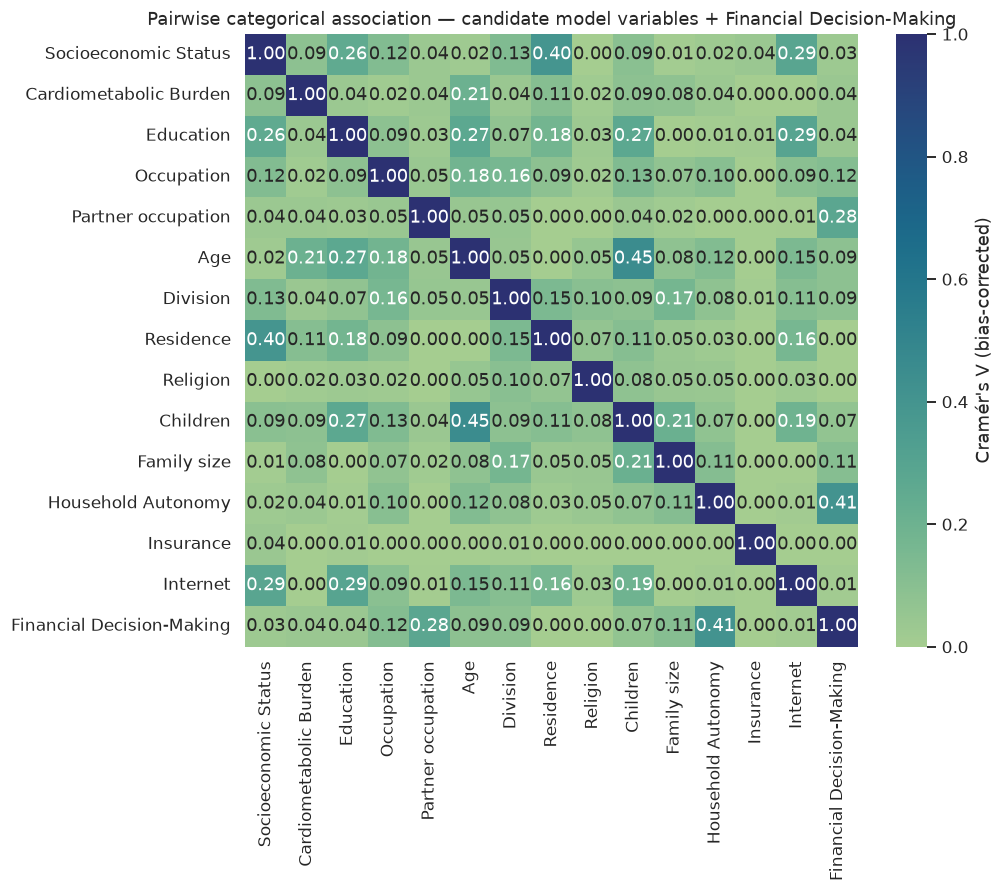

In [21]:
def cramers_v_corrected(x, y):
    tab = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tab)[0]
    n = tab.sum().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

assoc_vars = model_vars_fd
assoc = pd.DataFrame(index=assoc_vars, columns=assoc_vars, dtype=float)
for a in assoc_vars:
    for b in assoc_vars:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v_corrected(df_depression[a], df_depression[b])

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="crest", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Cramér's V (bias-corrected)"}, ax=ax)
plt.title("Pairwise categorical association — candidate model variables + Financial Decision-Making")
plt.tight_layout()
plt.show()

## 6. Summary of Findings

| # | Finding | Status |
|---|---|---|
| A | Depression/Anxiety, Occupation, Insurance, and IPV-attitude items share the same "extended module" sub-sample as the biomarker components | Documentation note -- covered in Section 2 |
| B | `Autonomy` silently recoded not-applicable cases to "0 = no autonomy" | Resolved -- `Household Autonomy` now built from `V743A`/`V743B`/`V743D` only; `V743F`'s "no earnings" case (64 women, 1.3%) preserved separately in `Financial Decision-Making` rather than discarded |
| C | `Marital status` / `Partner occupation` deterministic collinearity | Resolved -- `Marital status` dropped entirely, now constant under the currently-married-only filter |
| D | `Wealth=Poorest x Burden=3` interaction cell is thin (n=1) | Handled in Notebook 5 -- linear Burden as the primary interaction coding, collapsed 0/1/2+ as the sensitivity check, rather than a fully saturated categorical interaction |
| E | `IPV Attitude` "don't know" silently absorbed into "No" | Resolved -- now a 3-level variable (Rejects/Uncertain/Justifies); 62 women (1.3%) newly distinguished as "Uncertain" |
| F | `Insurance` complete separation (0 of 16 insured women screen positive, either outcome) | Resolved in Notebook 5 -- dropped from the primary adjustment set (11 covariates, not 12); passes GVIF cleanly above, so this is a separation problem specifically, not a collinearity one |
| G | Whether `Financial Decision-Making` and `IPV Attitude` belong in the adjustment set | Resolved in Notebook 5, Section 22 -- tested together as a 13-covariate sensitivity model; the interaction finding doesn't move, so both stay out of the primary 11-covariate set per the DAG reasoning in Section 5.1 |

Sample size: 30,078 eligible (ever-married) women -> 1,541 excluded for not being currently married
-> 28,537 -> 23,650 excluded for incomplete cardiometabolic biomarker components -> **final analytic
n = 4,887** (identical for depression and anxiety; see `Figure-2`, the STROBE attrition diagram, for
the full breakdown, and Section 2.2 above for how that final sample compares to the eligible
population on wealth, age, and division). No missing data remains in any of the 12 GVIF-checked
covariates -- the previously-flagged single "missing" Religion case was in fact a valid `V130 == 96`
("Others") response, not true missing data; `religion()` was corrected to route code 96 to "Others"
rather than silently imputing it. The candidate set clears GVIF^(1/(2*Df)) < 2 with no fix required
this round -- `Age` remains the highest term.

Two things this EDA doesn't attempt, worth naming rather than leaving implicit: the outcome cutoffs
(PHQ-9 >= 10, GAD-7 >= 10) are the primary specification throughout, with a stricter PHQ-9 >= 15
sensitivity check in Notebook 5 Section 19 rather than a full ordinal-outcome model here -- fitting
depression/anxiety severity as an ordinal (proportional-odds) outcome across all 4-5 bands would be a
reasonable further extension if reviewers ask for it, but it's a separate modeling effort, not an EDA
addition. And every distribution above is univariate or bivariate by construction; Notebook 5's own
diagnostics (GVIF here aside) are where the adjustment set's joint behavior gets checked.